# Cross-Domain Celebrity Retrieval — CLIP and ArcFace Fine Tuning


In [1]:
# in order to import functions

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import clip
from torch.utils.data import DataLoader
print('All imports OK')

All imports OK


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla V100-PCIE-16GB
VRAM   : 16.9 GB


### Data & saving checkpoints

In [7]:
# windows syntax:
# comp_train_dir="..\\data\\competition\\train\\train"
# comp_test_dir="..\\data\\competition\\test"

# linux syntax:
comp_train_dir="../data/competition/train/train"
comp_test_dir="../data/competition/test"

imgs_dir=comp_train_dir


In [8]:
# windows syntax:
# SAVE_DIR = ".\\models\\checkpoints\\clip_arcface_best"

# linux syntax: 
SAVE_DIR = "./models/checkpoints/clip_arcface_best"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {SAVE_DIR}')

Checkpoints will be saved to: ./models/checkpoints/clip_arcface_best


## Cell 5 — Load CLIP ViT-L/14

In [9]:
print('Loading CLIP ViT-L/14...')
clip_model, clip_preprocess = clip.load('ViT-L/14')

# Convert to float32 — CLIP loads as float16 on GPU by default
# ArcFace overflows to NaN in float16
clip_model = clip_model.float()
clip_model.eval()

EMBED_DIM = clip_model.visual.output_dim
# print(f'CLIP loaded on : {device}')
print(f'Embedding dim  : {EMBED_DIM}')  # 768 for ViT-L/14b

Loading CLIP ViT-L/14...
Embedding dim  : 768


## Build train/val:
Building training and validation sets, with an 80%-20% split

In [10]:
from src.datasets import TrainDataset

train_dataset = TrainDataset(comp_train_dir, clip_preprocess, min_images=2)
NUM_CLASSES   = train_dataset.num_classes

n_train = int(0.8 * len(train_dataset))
n_val   = len(train_dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

is_cuda = (device.type == 'cuda')
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=is_cuda)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=is_cuda)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train dataset: 250 identities, 5000 images
Train batches : 125
Val   batches : 16


## ArcFace head


In [11]:
from src.arcface_head import ArcFaceHead

arcface_head = ArcFaceHead(
    embedding_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    s=30.0,
    m=0.4
).to(device)

print(f'ArcFace head: {EMBED_DIM} → {NUM_CLASSES} classes')
print(f'Trainable params: {sum(p.numel() for p in arcface_head.parameters()):,}')

ArcFace head: 768 → 250 classes
Trainable params: 192,000


## Fine-tuning

Setting up:

In [12]:
# Freeze all CLIP params
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze last 6 transformer blocks + final LayerNorm + projection
for block in list(clip_model.visual.transformer.resblocks)[-6:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model.visual.ln_post.parameters():
    param.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)')

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clip_model.parameters()), 'lr': 5e-6},
    {'params': arcface_head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)





Trainable: 76,365,824 / 427,616,513 (17.9%)


Actual finetuning:

In [ ]:
torch.cuda.empty_cache()

In [13]:
from src.train import train_one_epoch
from src.retrieval import evaluate_retrieval

EPOCHS    = 10
best_top1 = 0.0

history = {
    'loss': [],
    'top1': [],
    'top10': []
}

print('Starting fine-tuning...\n')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(clip_model, arcface_head, train_loader, optimizer, device, epoch)
    scheduler.step()
    top1, top10 = evaluate_retrieval(clip_model, val_loader, device)
    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Top-1: {top1*100:.2f}% | Top-10: {top10*100:.2f}%')

    history['loss'].append(avg_loss)
    history['top1'].append(top1)
    history['top10'].append(top10)

    if top1 > best_top1:
        best_top1 = top1
        torch.save({
            'epoch'      : epoch,
            'clip_state' : clip_model.state_dict(),
            'head_state' : arcface_head.state_dict(),
            'top1'       : top1
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'   New best saved (Top-1={top1*100:.2f}%)')

print(f'\nTraining complete. Best Top-1: {best_top1*100:.2f}%')

Starting fine-tuning...



/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 1 | Batch 20/125 | Loss: 17.5821
  Epoch 1 | Batch 40/125 | Loss: 17.4772
  Epoch 1 | Batch 60/125 | Loss: 17.0269
  Epoch 1 | Batch 80/125 | Loss: 16.9561
  Epoch 1 | Batch 100/125 | Loss: 16.3816
  Epoch 1 | Batch 120/125 | Loss: 16.2269


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/2 | Loss: 17.0307 | Top-1: 54.50% | Top-10: 73.80%
   New best saved (Top-1=54.50%)
  Epoch 2 | Batch 20/125 | Loss: 15.3699
  Epoch 2 | Batch 40/125 | Loss: 14.1263
  Epoch 2 | Batch 60/125 | Loss: 14.5839
  Epoch 2 | Batch 80/125 | Loss: 14.0831


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 2 | Batch 100/125 | Loss: 13.6685
  Epoch 2 | Batch 120/125 | Loss: 13.2533


/home/disi/miniconda3/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/2 | Loss: 14.4401 | Top-1: 59.20% | Top-10: 74.30%
   New best saved (Top-1=59.20%)

Training complete. Best Top-1: 59.20%


## Testing & visualisation

In [ ]:
from src.generate_submission import generate_submission
from src.retrieval import visualise_retrieval

# windows syntax
# QUERY_DIR="..\\data\\competition\\test\\query"
# GALLERY_DIR="..\\data\\competition\\test\\gallery"

# linux syntax:
QUERY_DIR="../data/competition/test/query"
GALLERY_DIR="../data/competition/test/gallery"

# FINETUNED PERFORMANCE
clip_model.eval()
submission = generate_submission(
    QUERY_DIR, GALLERY_DIR,
    model=clip_model, preprocess=clip_preprocess, top_k=10
)

# Visualise 3 random queries
visualise_retrieval(QUERY_DIR, GALLERY_DIR,
                    clip_model, clip_preprocess,
                    num_queries=3, top_k=10)

## Cell 10 — Load Best Checkpoint
⚠️ Only run this after a **session reset**.
If you just finished Cell 9 in the same session, skip this and go to Cell 11.

In [15]:
CKPT_PATH = f'{SAVE_DIR}/best_model.pth'
ckpt = torch.load(CKPT_PATH, map_location=device)
clip_model.load_state_dict(ckpt['clip_state'])
clip_model.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (Top-1 = {ckpt["top1"]*100:.2f}%)')

Loaded checkpoint from epoch 2 (Top-1 = 59.20%)


## Cell 11 — Generate Exam Submission and evaluate accuracy EDIT
Update `QUERY_DIR` and `GALLERY_DIR` with the paths given on exam day.

Extracting query embeddings...
Extracting gallery embeddings...

Top-1  accuracy : 100.00%
Top-10 accuracy : 100.00%


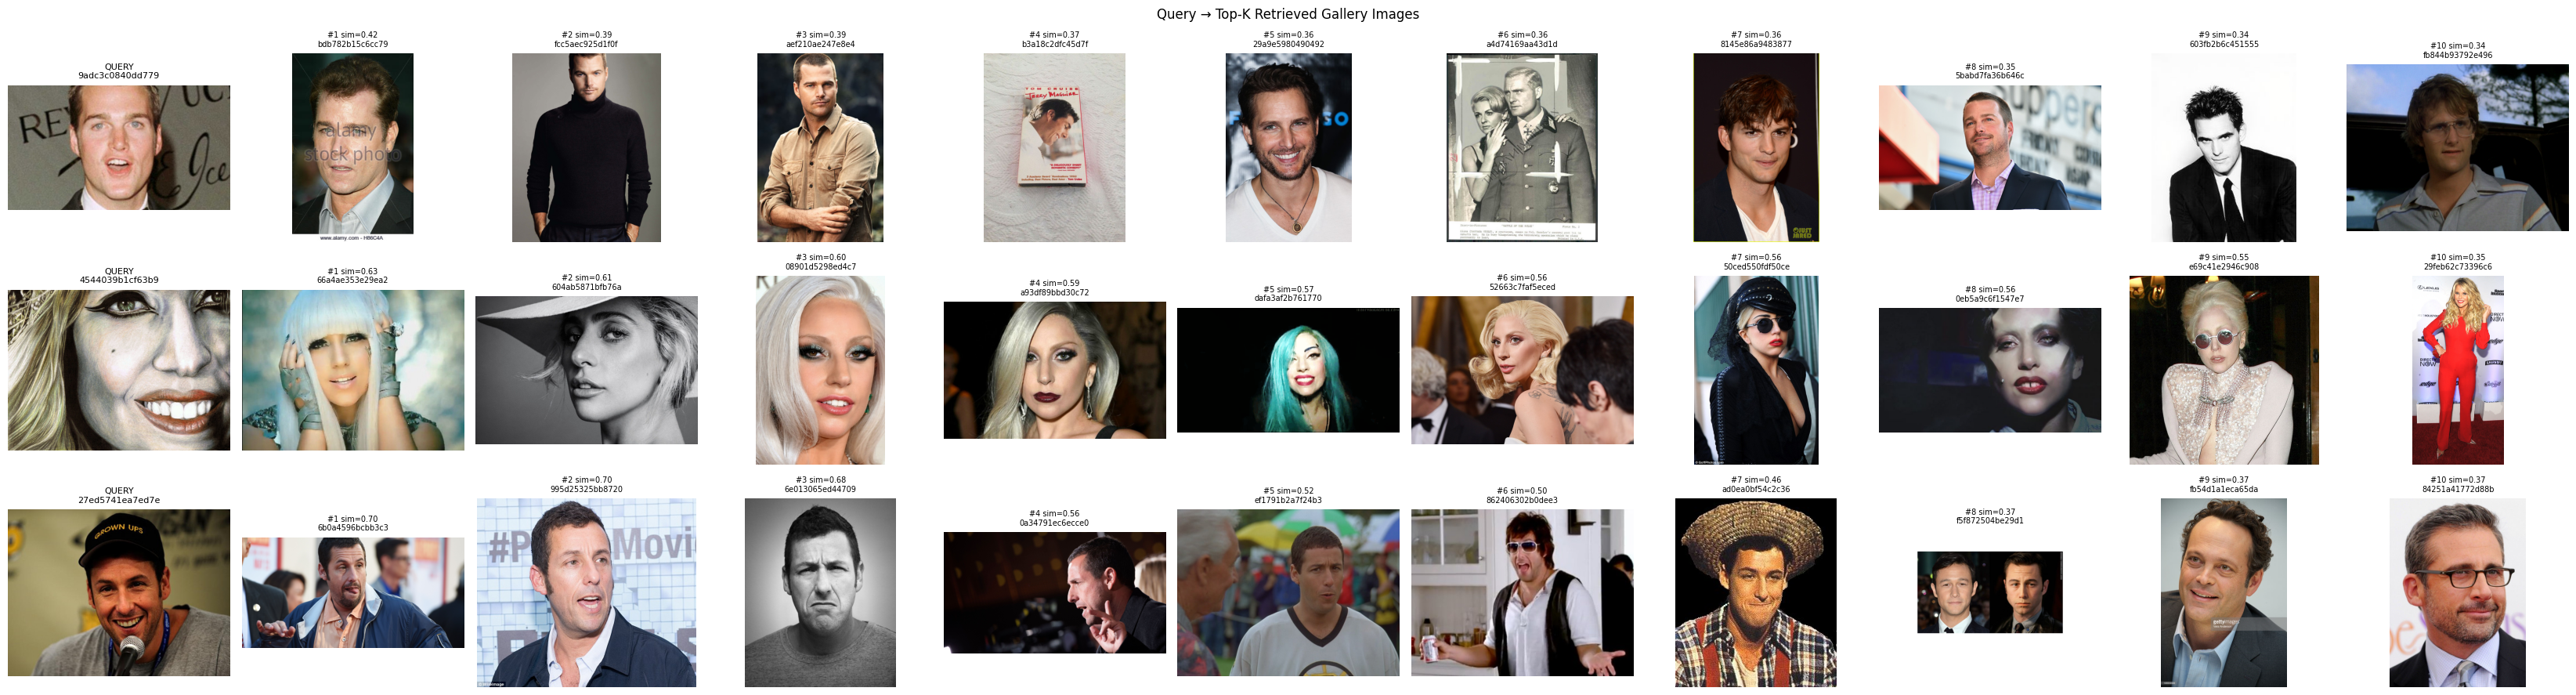

Submission ready: 300 queries
Example: ('b535aa4c3fa886b82028d3d91f77ed8b90984e4c.jpg', ['6ab88e59c494cd5a709eeb046d50fbfbafcc77c1.jpg', 'f16052ea4db70b7488a17d08be78cdbf1a99895b.jpg', 'b24cda988bc7689e0fbf1050bbeb3c8a591cd83c.jpg', 'ce684c9a126fb78d7eb65cd76204f6953c7281b9.jpg', '2afc8163f5732f727bf4b7c53d78bcd6ea357d66.jpg', '667b6d39f75f45ae5756c925112948713a2da023.jpg', '524cfd280b02d50606dc5776ce52b336594df206.jpg', '86ad9298d1c48fc6c9a4806869bf8a1e1b72a56e.jpg', '590e48b11bdc3f3895ba8790ccc849133410d87f.jpg', '15ff65db9bfa12d97cd4f3342a7c72e5fa960650.jpg'])


In [16]:
# BEST MODEL PERFORMANCE

clip_model.eval()
submission = generate_submission(
    QUERY_DIR, GALLERY_DIR,
    model=clip_model,
    preprocess=clip_preprocess,
    top_k=10
)

# Evaluate accuracy
correct_top1 = 0
correct_top10 = 0
for query_filename, retrieved_list in submission.items():
    query_identity    = '_'.join(query_filename.split('_')[:-1])
    top1_identity     = '_'.join(retrieved_list[0].split('_')[:-1])
    if top1_identity == query_identity:
        correct_top1 += 1
    retrieved_ids = ['_'.join(r.split('_')[:-1]) for r in retrieved_list]
    if query_identity in retrieved_ids:
        correct_top10 += 1

total = len(submission)
print(f'\nTop-1  accuracy : {correct_top1  / total * 100:.2f}%')
print(f'Top-10 accuracy : {correct_top10 / total * 100:.2f}%')

# Visualise 3 random queries
visualise_retrieval(QUERY_DIR, GALLERY_DIR,
                    clip_model, clip_preprocess,
                    num_queries=3, top_k=10)

print(f'Submission ready: {len(submission)} queries')
print(f'Example: {list(submission.items())[0]}')import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['loss'], marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')

ax2.plot(epochs, history['top1'], marker='o', label='Top-1')
ax2.plot(epochs, history['top10'], marker='o', label='Top-10')
ax2.set_title('Retrieval Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# Uncomment to submit:
# submit(submission, 'Your Group Name')

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['loss'], marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')

ax2.plot(epochs, history['top1'], marker='o', label='Top-1')
ax2.plot(epochs, history['top10'], marker='o', label='Top-10')
ax2.set_title('Retrieval Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [ ]:
# import os
# import random
# import matplotlib.pyplot as plt
# import PIL.Image as PILImage

# def visualise_test_submission(query_dir, gallery_dir, submission_dict, num_queries=3, top_k=5):
#     """
#     Visualises submission dictionary mapping by looking up actual files
#     inside the final query_dir and gallery_dir paths.
#     """
#     # Pick a few sample queries from the submission dictionary keys
#     q_names = list(submission_dict.keys())
#     if not q_names:
#         print("Submission dictionary is empty! Run the generation block first.")
#         return

#     q_sample = random.sample(q_names, min(num_queries, len(q_names)))

#     # Construct plotting grid
#     fig, axes = plt.subplots(len(q_sample), top_k + 1,
#                              figsize=(3 * (top_k + 1), 3 * len(q_sample)))

#     # Handle single row formatting edge case
#     if num_queries == 1 or len(q_sample) == 1:
#         axes = [axes]

#     for row, q_name in enumerate(q_sample):
#         # 1. Render original test Query image
#         q_path = os.path.join(query_dir, q_name)
#         if os.path.exists(q_path):
#             q_img = PILImage.open(q_path).convert('RGB')
#             axes[row][0].imshow(q_img)
#         axes[row][0].set_title(f'QUERY\n{q_name[:15]}', fontsize=8, color='blue')
#         axes[row][0].axis('off')

#         # 2. Render ranked predictions returned by the model
#         retrieved_list = submission_dict[q_name]
#         for col in range(top_k):
#             ax = axes[row][col + 1]
#             if col < len(retrieved_list):
#                 g_name = retrieved_list[col]
#                 g_path = os.path.join(gallery_dir, g_name)

#                 if os.path.exists(g_path):
#                     g_img = PILImage.open(g_path).convert('RGB')
#                     ax.imshow(g_img)
#                 ax.set_title(f'Rank #{col+1}\n{g_name[:15]}', fontsize=7)
#             ax.axis('off')

#     plt.suptitle('Submission Preview: Target Queries → Top Predicted Gallery Matches', fontsize=12, weight='bold')
#     plt.tight_layout()
#     plt.show()

# # Run the preview visualization pass using your live active test folders
# visualise_test_submission(
#     query_dir=QUERY_DIR,
#     gallery_dir=GALLERY_DIR,
#     submission_dict=submission,
#     num_queries=3,
#     top_k=10
# )

In [ ]:
# from src.generate_submission import visualise_test_submission

# # Run the preview visualization pass using your live active test folders
# visualise_test_submission(
#     query_dir=QUERY_DIR,
#     gallery_dir=GALLERY_DIR,
#     submission_dict=submission,
#     num_queries=3,
#     top_k=10
# )

In [ ]:
# import json
# import requests

In [ ]:
# def submit(results, groupname, url):
#     res = {}
#     res['groupname'] = groupname
#     res['images'] = results
#     res = json.dumps(res)
#     # print(res)
#     response = requests.post(url, res)
#     try:
#         result = json.loads(response.text)
#         print(f"accuracy is {result['accuracy']}")
#     except json.JSONDecodeError:
#         print(f"ERROR: {response.text}")


# submit(results=submission,groupname="caggol",url="http://videosim.disi.unitn.it:3001/retrieval/")

problematic predictions

In [ ]:
# The necessary imports (torch, clip, FaceGallery, EmbeddingExtractor, RetrievalEvaluator, plot_worst_retrievals, plot_confusion_identities) are already handled by previous cells or are globally available.

# DEVICE and other global variables (QUERY_DIR, GALLERY_DIR) are already defined in previous cells.
# DEVICE is available as 'device'
# QUERY_DIR is available as '/content/celebrity_retrieval/test/query'
# GALLERY_DIR is available as '/content/celebrity_retrieval/test/gallery'
# CKPT_PATH is available as './celebrity_retrieval/best_model.pth'

# 1. Load model and checkpoint
# The clip_model and clip_preprocess are already loaded in a previous cell.
# arcface_head is also already instantiated.

print(f"Loading checkpoint from {CKPT_PATH}")
ckpt = torch.load(CKPT_PATH, map_location=device)
clip_model.load_state_dict(ckpt["clip_state"])
clip_model.eval()

# Load ArcFace head state if available in the checkpoint
if "head_state" in ckpt:
    arcface_head.load_state_dict(ckpt["head_state"])
    arcface_head.eval()
else:
    print("Warning: 'head_state' not found in checkpoint. ArcFace head will not be loaded from checkpoint.")

print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (Top-1 = {ckpt["top1"]*100:.2f}%)')

# 2. Load dataset
# Changed nested=True to nested=False to match the likely flat structure of the test data
query_gal   = FaceGallery(QUERY_DIR,   nested=False)
index_gal   = FaceGallery(GALLERY_DIR, nested=False)

# 3. Extract embedding
extractor = EmbeddingExtractor(clip_model, clip_preprocess, device)
q_emb = extractor.extract(query_gal, arcface_head=arcface_head)
i_emb = extractor.extract(index_gal, arcface_head=arcface_head)

# 4. Evaluate
evaluator = RetrievalEvaluator(query_gal, index_gal, q_emb, i_emb)
results   = evaluator.run(top_k=20, exclude_self=True)
metrics   = evaluator.global_metrics(results)

print("\n── global metrics ──────────────────")
for k, v in metrics.items():
    print(f"  {k:8s}  {v:.4f}")

# --- Inserting labels demonstration ---
print("\n── Sample Labels from Results ──────────────────")
for i, res in enumerate(results[:3]): # Print labels for the first 3 results
    print(f"Query {i+1}:")
    print(f"  Query ID: {res.query_id}")
    print(f"  Top-5 Retrieved IDs: {res.top_k_ids[:5]}")
    print(f"  Rank of Best Match: {res.rank_of_best}")
# ──────────────────────────────────────

# 5. Visualize
plot_worst_retrievals(
    results,
    n_queries   = 12,   # the 12 most problematic queries
    n_retrieved = 8,
    save_path   = "worst_retrievals.png"
)

plot_confusion_identities(
    results,
    top_n_confused = 20,
    save_path       = "confusion_matrix.png"
)



In [ ]:
# # Additional plot for top 10 most confused identities, as requested by the user
# print("\n── Confusion Matrix for Top 10 Most Confused Identities ──────────────────")
# plot_confusion_identities(
#     results,
#     top_n_confused = 10, # Limiting to the 10 most confused identities
#     save_path       = "confusion_matrix_top10.png"
# )

### Save Best Model Configuration to Google Drive

In [ ]:
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

# # Define the path in Google Drive to save the checkpoint
# drive_save_path = '/content/drive/MyDrive/celebrity_retrieval_best_model.pth'

# # Save the checkpoint (which contains clip_state, head_state, epoch, and top1 accuracy)
# torch.save(ckpt, drive_save_path)

# print(f'Best model configuration saved to: {drive_save_path}')